In [32]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

### Task 1: Exploratory Data Analysis (EDA) 

In [33]:
data = pd.read_csv('Pharma_Industry (1).csv')
data.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [34]:
data.shape

(500, 6)

In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [36]:
data.isna().sum()

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

In [37]:
data.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


In [38]:
data.duplicated().sum()

np.int64(0)

In [39]:
data["Drug Response"].value_counts()


Drug Response
1    260
0    240
Name: count, dtype: int64

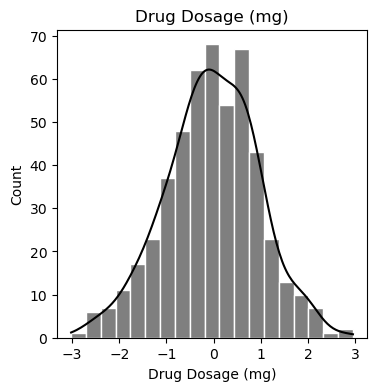

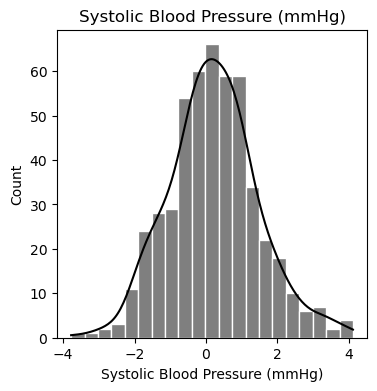

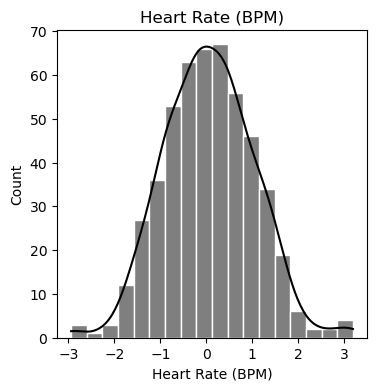

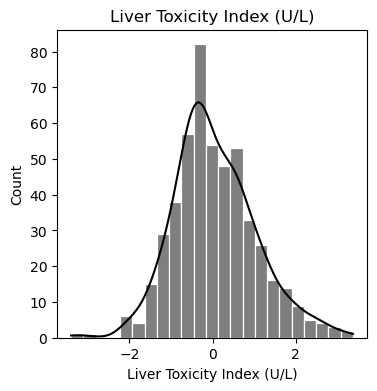

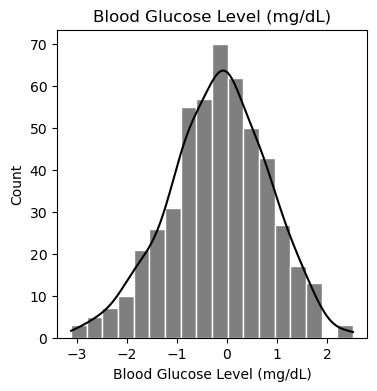

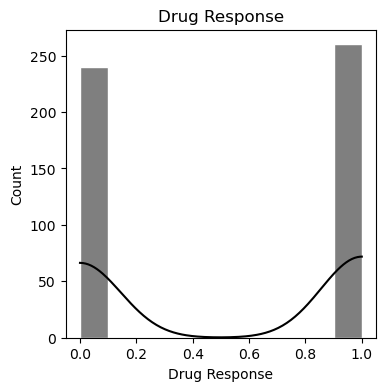

In [40]:
# histplot
cols = data.columns

for col in cols:
    plt.figure(figsize=(4,4))
    sns.histplot(data[col], kde=True, color='black', edgecolor='white')
    plt.title(col)
    plt.show()

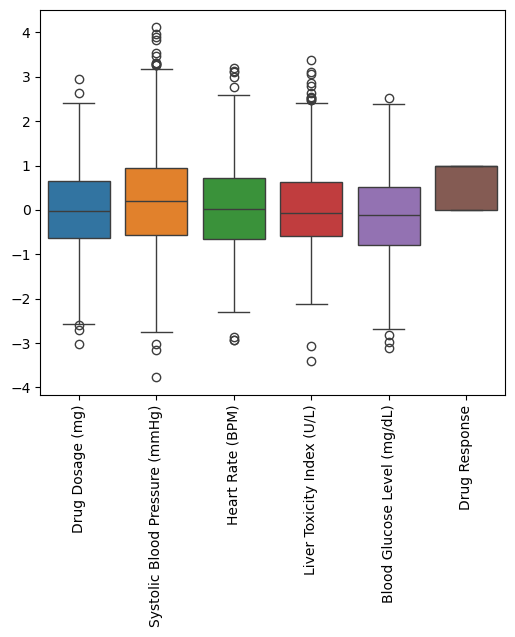

In [41]:
# box plot
plt.figure(figsize=(6,5))
sns.boxplot(data)
plt.xticks(rotation=90)
plt.show()

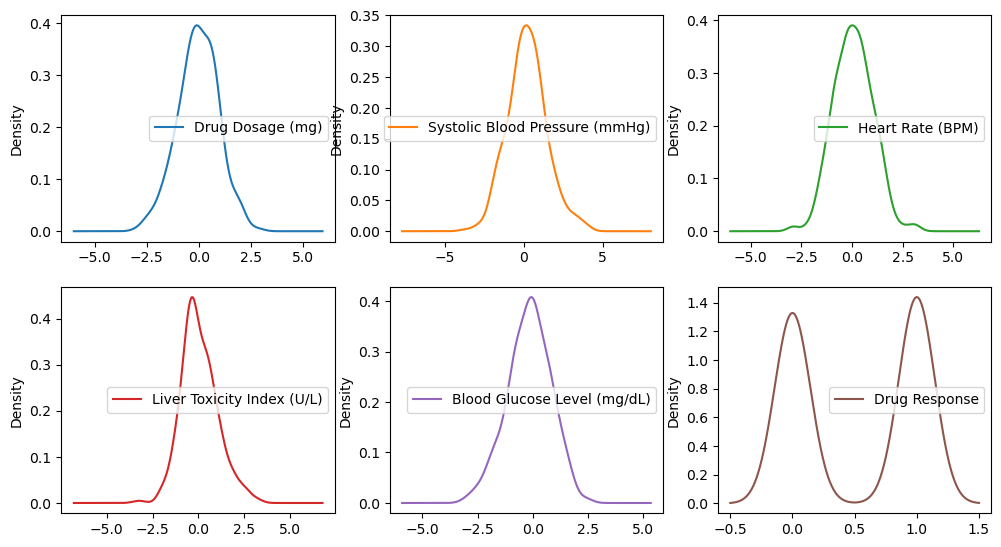

In [42]:
# density plot
data.plot(kind='density', subplots=True,  layout=(3,3),figsize=(12,10),sharex=False)
plt.show()

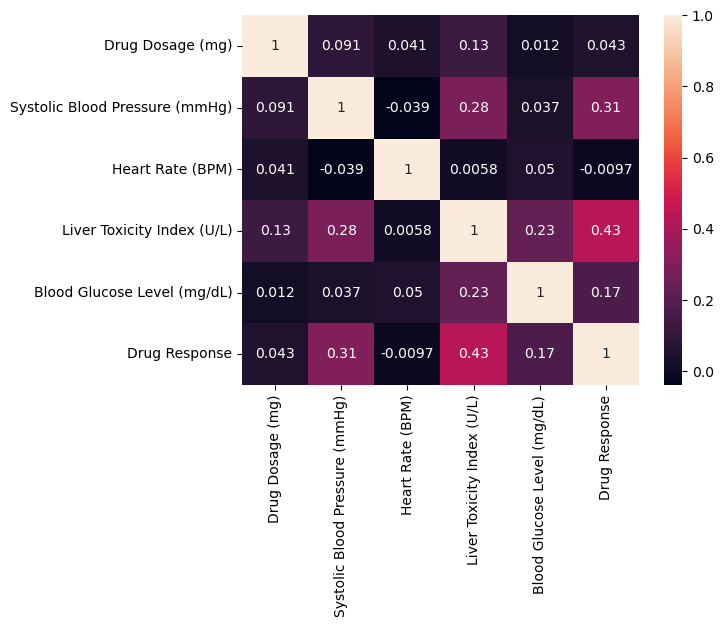

In [43]:
# correlation
sns.heatmap(data.corr(), annot=True)
plt.show()

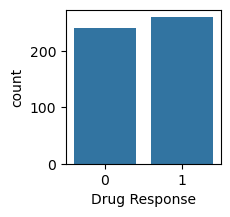

In [44]:
# count plot
plt.figure(figsize=(2,2))
sns.countplot(data=data,x='Drug Response')
plt.show()

### Task 2: Data Preprocessing 

In [45]:
# split features and target

X = data.drop('Drug Response', axis=1)
y = data['Drug Response']

### Task 3: Data Visualization 

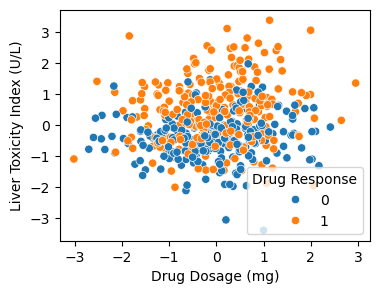

In [46]:
# scatter plot
plt.figure(figsize=(4,3))
sns.scatterplot(data,x='Drug Dosage (mg)', 
                y='Liver Toxicity Index (U/L)', 
                hue='Drug Response')
plt.show()

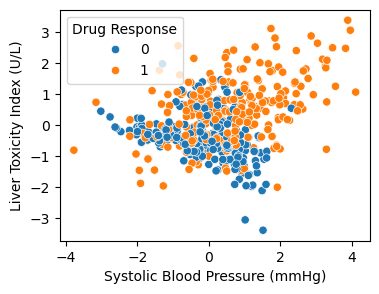

In [47]:
# scatter plot
plt.figure(figsize=(4,3))
sns.scatterplot(data,x='Systolic Blood Pressure (mmHg)', 
                y='Liver Toxicity Index (U/L)', 
                hue='Drug Response')
plt.show()

In [48]:
# pair plot 
# sns.pairplot(data,hue='Drug Response')
# plt.show()

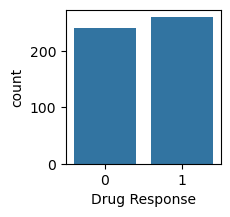

In [49]:
# balanced data
plt.figure(figsize=(2,2))
sns.countplot(data,x='Drug Response')
plt.show()

### Task 4: SVM Implementation 

In [50]:
# train_test_split

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((400, 5), (100, 5), (400,), (100,))

In [51]:
from sklearn.svm import SVC

In [52]:
# model 
model = SVC(C=1.0, gamma=1.0)
model.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,1.0
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [53]:
# training predicton

yhat_train = model.predict(X_train)
yhat_train

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1,
       1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0,

In [54]:
from sklearn.metrics import confusion_matrix, classification_report

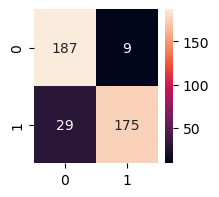

In [55]:
# confusion matrix

cn = confusion_matrix(y_train,yhat_train)

plt.figure(figsize=(2,2))
sns.heatmap(cn, annot=True, fmt='d')
plt.show()


In [56]:
# report
print(classification_report(y_train, yhat_train))

              precision    recall  f1-score   support

           0       0.87      0.95      0.91       196
           1       0.95      0.86      0.90       204

    accuracy                           0.91       400
   macro avg       0.91      0.91      0.90       400
weighted avg       0.91      0.91      0.90       400



In [57]:
# testing prediction

yhat_test = model.predict(X_test)
yhat_test

array([1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1])

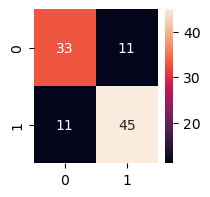

In [58]:
# confusion matrox

cn = confusion_matrix(y_test,yhat_test)

plt.figure(figsize=(2,2))
sns.heatmap(cn, annot=True, fmt='d')
plt.show()

In [59]:
# report

print(classification_report(y_train, yhat_train))

              precision    recall  f1-score   support

           0       0.87      0.95      0.91       196
           1       0.95      0.86      0.90       204

    accuracy                           0.91       400
   macro avg       0.91      0.91      0.90       400
weighted avg       0.91      0.91      0.90       400



### Task 5: Visualization of SVM Results 

In [64]:
X_test = X_test.to_numpy()
y_test = y_test.to_numpy()


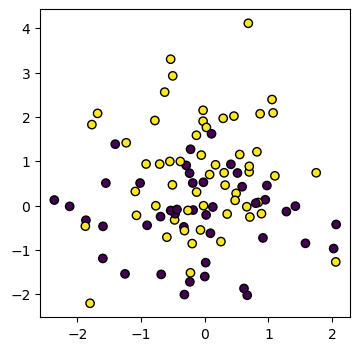

In [65]:
plt.figure(figsize=(4,4))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors='black')
plt.show()

### Task 6: Parameter Tuning and Optimization 

In [67]:
from sklearn.metrics import accuracy_score

In [69]:
configs = [
    {'kernel': 'linear', 'C': 0.1},
    {'kernel': 'linear', 'C': 1},
    {'kernel': 'rbf', 'C': 1, 'gamma': 'scale'},
    {'kernel': 'rbf', 'C': 10, 'gamma': 0.1},
    {'kernel': 'rbf', 'C': 1, 'gamma': 10}  # overfitting case
]

for cfg in configs:
    model = SVC(**cfg)
    model.fit(X_train, y_train.ravel())
    yhat_test = model.predict(X_test)
    
    print(cfg, "Accuracy:", accuracy_score(y_test, yhat_test))

{'kernel': 'linear', 'C': 0.1} Accuracy: 0.77
{'kernel': 'linear', 'C': 1} Accuracy: 0.78
{'kernel': 'rbf', 'C': 1, 'gamma': 'scale'} Accuracy: 0.82
{'kernel': 'rbf', 'C': 10, 'gamma': 0.1} Accuracy: 0.83
{'kernel': 'rbf', 'C': 1, 'gamma': 10} Accuracy: 0.6


C:\Users\Thasin\AppData\Local\Temp\ipykernel_12356\796527220.py:11: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  model.fit(X_train, y_train.ravel())
C:\Users\Thasin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\Thasin\AppData\Local\Temp\ipykernel_12356\796527220.py:11: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  model.fit(X_train, y_train.ravel())
C:\Users\Thasin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\Thasin\AppData\Local\Temp\ipykernel_12356\796527220.py:11: FutureWarning: Series.ra

### Task 7: Comparison and Analysis 

##### Compare SVM performance

##### Analyse SVM strengths and weaknesses 

##### practical implications of SVM in real-world classification tasks. 